# Chapter 8

## 8.1 test T1 and T2 
* T1 多给ID门，此门数量无限制。
* T2 同理。

T2也就是相对相位一般先出问题。

此为定性比较，具体数字待定。

In [11]:
import os
import time
import matplotlib.pyplot as plt 
from qiskit import QuantumCircuit, qasm2
from quark import Task

def quark_comp(qiskit_circ, repeat_count=1, my_job='my_job', chip='Yudu', target_qubits=[]):
    # circ trans
    qasm_circ = qasm2.dumps(qiskit_circ)
    # tmgr
    token = os.getenv('QUARK_API_TOKEN')
    tmgr = Task(token) # task manager
    task = {
    'chip': chip,  
    'name': my_job,  
    'circuit':qasm_circ, # circuit written in OpenQASM2.0
    'compile': True, # 可能用模拟机。(你要是自信自己写的全是基础门就用False.)
    'options':{
        'correct': False,
        'target_qubits': target_qubits # 具体bit而非范围。 
    }
    }

    tid = tmgr.run(task, repeat=repeat_count) # shots = repeat*1024
    res = tmgr.result(tid)
    while not res:
        time.sleep(1)
        res = tmgr.result(tid)
    display(res)

    data = res['count']
    bases = sorted(data) # 00, 01, 10, 11
    count = [data[base] for base in bases]
    plt.bar(bases, count)
    plt.xticks(rotation=45)
    return data

{'count': {'1': 901, '0': 123},
 'corrected': {},
 'chip': 'Yudu',
 'circuit': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[1];\ncreg c[1];\nx q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\

{'1': 901, '0': 123}

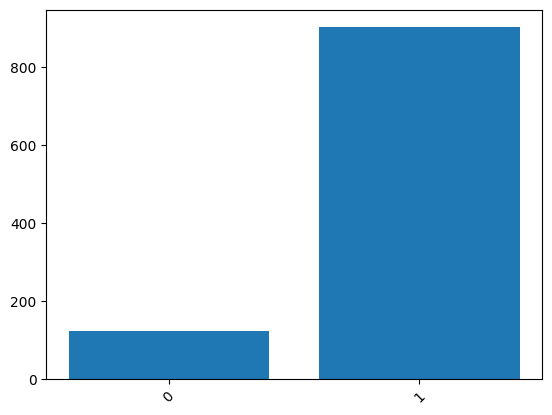

In [ ]:
# test T1
circ = QuantumCircuit(1, 1)
circ.x(0)
for i in range(10024): 
    circ.id(0)
    circ.barrier()
circ.measure(0, 0)

quark_comp(circ)

{'count': {'1': 900, '0': 124},
 'corrected': {},
 'chip': 'Yudu',
 'circuit': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[1];\ncreg c[1];\nx q[0];\nh q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarrier q[0];\nid q[0];\nbarri

{'1': 900, '0': 124}

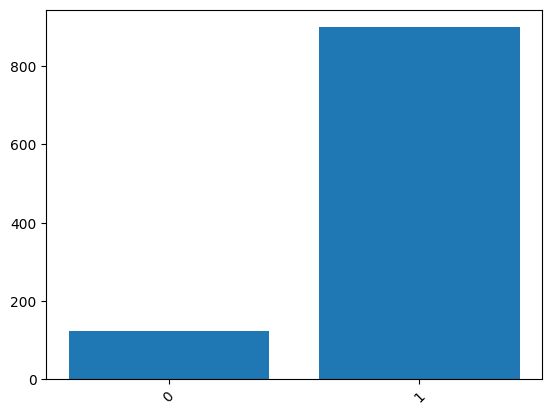

In [ ]:
# test T2
circ = QuantumCircuit(1, 1)
circ.x(0)
circ.h(0)
for i in range(1024):
    circ.id(0)
    circ.barrier()
circ.h(0)
circ.measure(0, 0)
quark_comp(circ)

## 8.2 纠错

1. 两种错误：
* 比特翻转纠错: 用3个比特保证第一个比特不变。
* 相位翻转纠错：用3个比特保证第一个相位不变。

2. 同时纠错**shor 码**，9个，心累。

在真实的量子计算机上可以看出来显然是越纠越错。

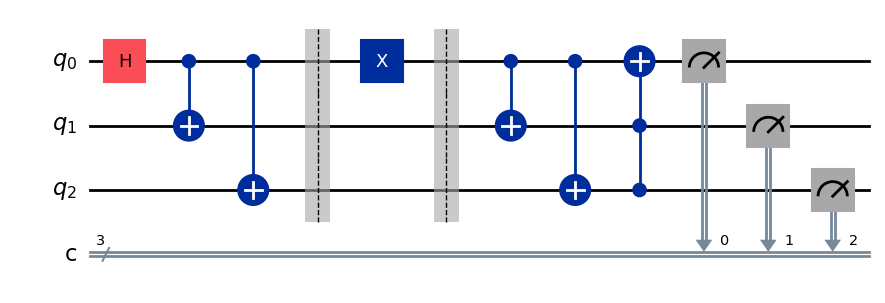

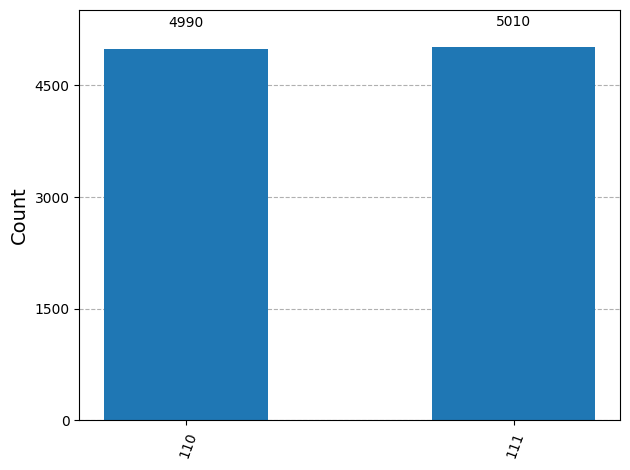

In [ ]:
# bit filp
from qiskit_aer import Aer
from qiskit import transpile
from qiskit.visualization import plot_histogram
circ = QuantumCircuit(3, 3)
circ.h(0)
circ.cx([0, 0], [1, 2])
circ.barrier()
circ.x(0)
circ.barrier()
circ.cx([0, 0], [1, 2])
circ.ccx(1, 2, 0)
circ.measure([0, 1, 2], [0, 1, 2])
display(circ.draw('mpl'))

backend = Aer.get_backend('statevector_simulator') # different simulator
transpiled_circ = transpile(circ, backend) 
job = backend.run(transpiled_circ, shots=10000) 
result = job.result() 
counts = result.get_counts()
plot_histogram(counts) 


{'count': {'100': 25,
  '011': 74,
  '110': 628,
  '111': 145,
  '101': 82,
  '010': 49,
  '000': 10,
  '001': 11},
 'corrected': {},
 'chip': 'Baihua',
 'circuit': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[3];\ncx q[0],q[1];\ncx q[0],q[2];\nh q[0];\nh q[1];\nh q[2];\nbarrier q[0],q[1],q[2];\nz q[0];\nbarrier q[0],q[1],q[2];\nh q[0];\nh q[1];\nh q[2];\ncx q[0],q[1];\ncx q[0],q[2];\nccx q[1],q[2],q[0];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];',
 'transpiled': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[78];\ncreg c[3];\ncx q[76],q[75];\ncx q[76],q[77];\nh q[75];\nh q[76];\nh q[77];\nbarrier q[76],q[75],q[77];\nz q[76];\nbarrier q[76],q[75],q[77];\nh q[76];\nh q[75];\nh q[77];\ncx q[76],q[75];\ncx q[76],q[77];\nh q[76];\ncx q[77],q[76];\ntdg q[76];\ncx q[75],q[76];\nt q[76];\ncx q[77],q[76];\nt q[77];\ntdg q[76];\ncx q[75],q[76];\nt q[76];\nh q[76];\ncx q[76],q[75];\ncx q[75],q[76];\ncx q[76],q[75];\ncx q[76],q[77];\nt q[76];\ntdg q[77];\ncx 

{'100': 25,
 '011': 74,
 '110': 628,
 '111': 145,
 '101': 82,
 '010': 49,
 '000': 10,
 '001': 11}

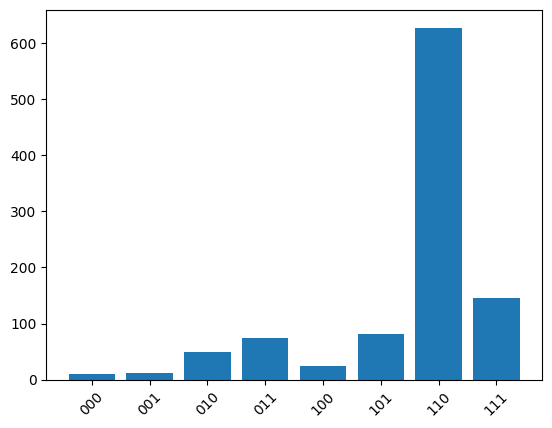

In [45]:
quark_comp(circ, chip='Baihua')

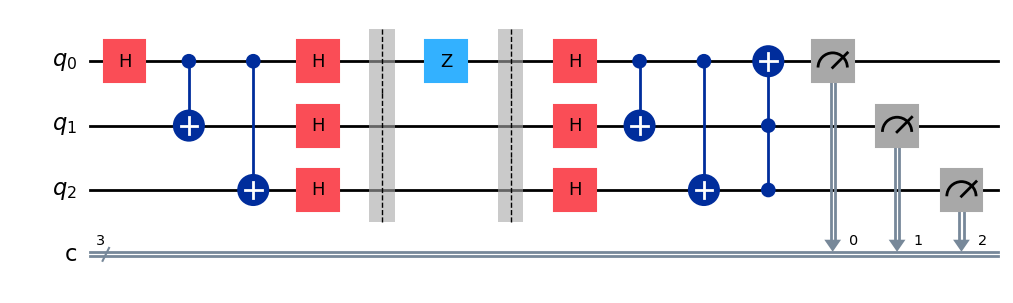

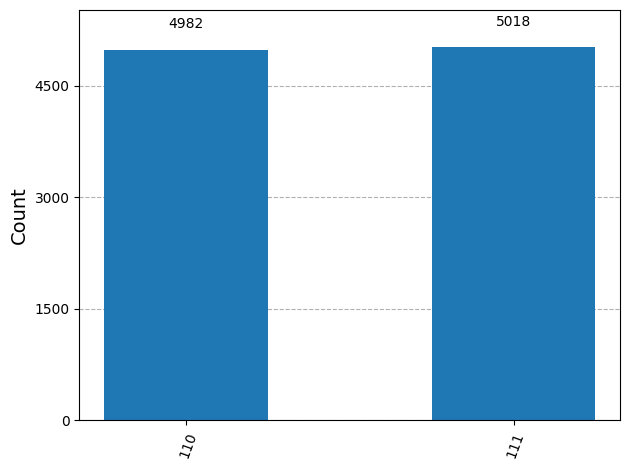

In [48]:
# phase error
circ = QuantumCircuit(3, 3)
circ.h(0)
circ.cx([0, 0], [1, 2])
circ.h([0, 1, 2])
circ.barrier([0, 1, 2])
circ.z(0)
circ.barrier([0, 1, 2])
circ.h([0, 1, 2])
circ.cx([0, 0], [1, 2])
circ.ccx(1, 2, 0)
circ.measure([0, 1, 2], [0, 1, 2])
display(circ.draw('mpl'))

backend = Aer.get_backend('statevector_simulator') # different simulator
transpiled_circ = transpile(circ, backend) 
job = backend.run(transpiled_circ, shots=10000) 
result = job.result() 
counts = result.get_counts()
plot_histogram(counts) 

{'count': {'110': 160,
  '111': 526,
  '011': 87,
  '101': 113,
  '010': 46,
  '100': 68,
  '001': 10,
  '000': 14},
 'corrected': {},
 'chip': 'Baihua',
 'circuit': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[3];\ncreg c[3];\nh q[0];\ncx q[0],q[1];\ncx q[0],q[2];\nh q[0];\nh q[1];\nh q[2];\nbarrier q[0],q[1],q[2];\nz q[0];\nbarrier q[0],q[1],q[2];\nh q[0];\nh q[1];\nh q[2];\ncx q[0],q[1];\ncx q[0],q[2];\nccx q[1],q[2],q[0];\nmeasure q[0] -> c[0];\nmeasure q[1] -> c[1];\nmeasure q[2] -> c[2];',
 'transpiled': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[78];\ncreg c[3];\nh q[76];\ncx q[76],q[75];\ncx q[76],q[77];\nh q[75];\nh q[76];\nh q[77];\nbarrier q[76],q[75],q[77];\nz q[76];\nbarrier q[76],q[75],q[77];\nh q[76];\nh q[75];\nh q[77];\ncx q[76],q[75];\ncx q[76],q[77];\nh q[76];\ncx q[77],q[76];\ntdg q[76];\ncx q[75],q[76];\nt q[76];\ncx q[77],q[76];\nt q[77];\ntdg q[76];\ncx q[75],q[76];\nt q[76];\nh q[76];\ncx q[76],q[75];\ncx q[75],q[76];\ncx q[76],q[75];\ncx q[76],q[77];\nt q[7

{'110': 160,
 '111': 526,
 '011': 87,
 '101': 113,
 '010': 46,
 '100': 68,
 '001': 10,
 '000': 14}

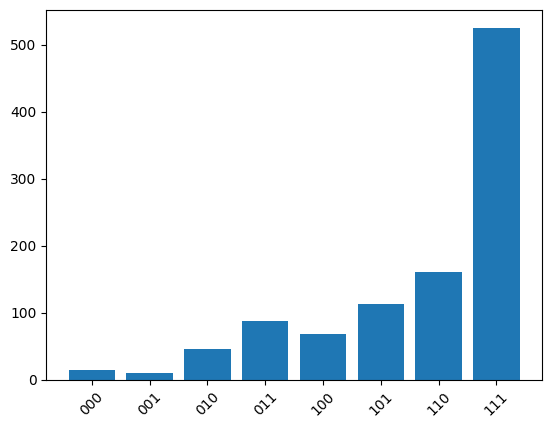

In [49]:
quark_comp(circ, chip='Baihua')

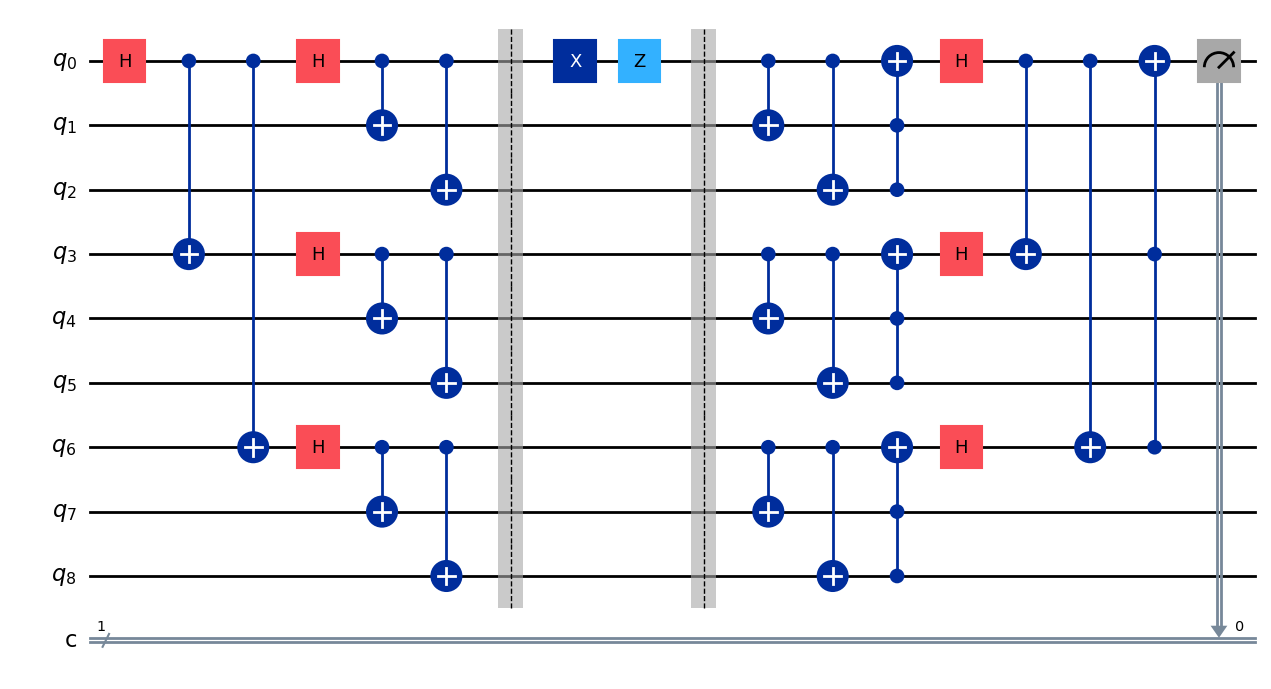

In [77]:
# shor 码
circ = QuantumCircuit(9, 1)
circ.h(0)
circ.cx([0, 0], [3, 6])
circ.h([0, 3, 6])
circ.cx([0, 0, 3, 3, 6, 6], [1, 2, 4, 5, 7, 8])
circ.barrier([i for i in range(9)])
circ.x(0)
circ.z(0)
circ.barrier([i for i in range(9)])
circ.cx([0, 0, 3, 3, 6, 6], [1, 2, 4, 5, 7, 8])
for i in [3 * j for j in range(3)]:
    circ.ccx(i + 2, i + 1, i)
circ.h([0, 3, 6])
circ.cx([0, 0], [3, 6])
circ.ccx(3, 6, 0)
circ.measure(0, 0)
display(circ.draw('mpl'))

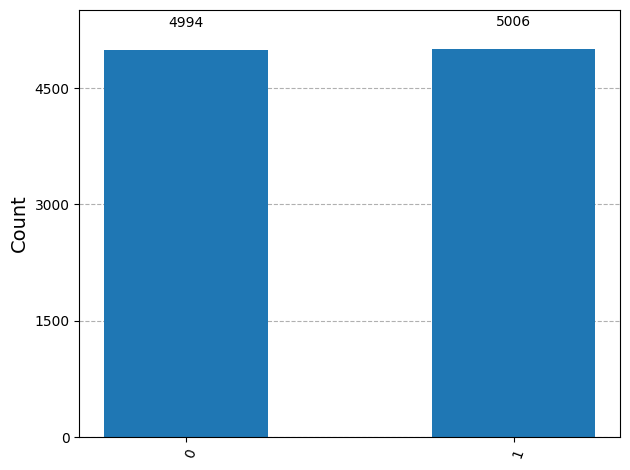

In [78]:
backend = Aer.get_backend('statevector_simulator') # different simulator
transpiled_circ = transpile(circ, backend) 
job = backend.run(transpiled_circ, shots=10000) 
result = job.result() 
counts = result.get_counts()
plot_histogram(counts) 

{'count': {'1': 468, '0': 556},
 'corrected': {},
 'chip': 'Baihua',
 'circuit': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[9];\ncreg c[1];\nh q[0];\ncx q[0],q[3];\ncx q[0],q[6];\nh q[0];\nh q[3];\nh q[6];\ncx q[0],q[1];\ncx q[0],q[2];\ncx q[3],q[4];\ncx q[3],q[5];\ncx q[6],q[7];\ncx q[6],q[8];\nbarrier q[0],q[1],q[2],q[3],q[4],q[5],q[6],q[7],q[8];\nx q[0];\nz q[0];\nbarrier q[0],q[1],q[2],q[3],q[4],q[5],q[6],q[7],q[8];\ncx q[0],q[1];\ncx q[0],q[2];\ncx q[3],q[4];\ncx q[3],q[5];\ncx q[6],q[7];\ncx q[6],q[8];\nccx q[2],q[1],q[0];\nccx q[5],q[4],q[3];\nccx q[8],q[7],q[6];\nh q[0];\nh q[3];\nh q[6];\ncx q[0],q[3];\ncx q[0],q[6];\nccx q[3],q[6],q[0];\nmeasure q[0] -> c[0];',
 'transpiled': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[48];\ncreg c[1];\nh q[43];\ncx q[43],q[42];\ncx q[43],q[44];\nh q[42];\nh q[43];\nh q[44];\ncx q[42],q[41];\ncx q[45],q[44];\ncx q[43],q[42];\ncx q[44],q[45];\ncx q[42],q[43];\ncx q[45],q[44];\ncx q[43],q[42];\ncx q[46],q[45];\ncx q[43],q[44];\ncx q[42],q[

{'1': 468, '0': 556}

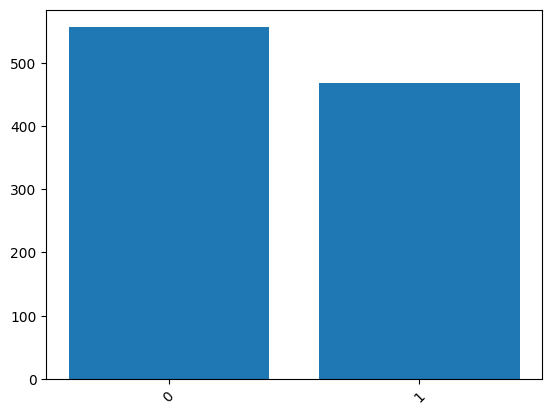

In [79]:
quark_comp(circ, chip='Baihua')

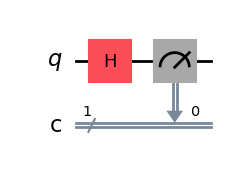

{'count': {'1': 527, '0': 497},
 'corrected': {},
 'chip': 'Baihua',
 'circuit': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[1];\ncreg c[1];\nh q[0];\nmeasure q[0] -> c[0];',
 'transpiled': 'OPENQASM 2.0;\ninclude "qelib1.inc";\nqreg q[1];\ncreg c[1];\nh q[0];\nbarrier q[0];\nmeasure q[0] -> c[0];',
 'qlisp': "[(('U', 1.5707963267948966, 0.0, 3.141592653589793), 'Q0'),\n('Barrier', ('Q0',)),\n(('Measure', 0), 'Q0')]",
 'tid': 2601042032282033183,
 'error': '',
 'status': 'Finished',
 'created': '2026-01-04 20:32:29.134532',
 'finished': '2026-01-04 20:32:30.507102'}

{'1': 527, '0': 497}

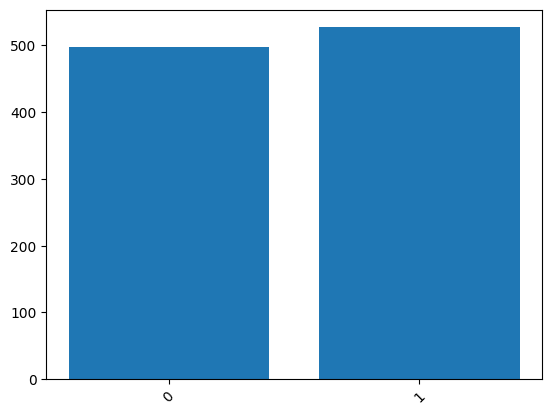

In [80]:
# shor 码
circ = QuantumCircuit(1, 1)
circ.h(0)
circ.measure(0, 0)
display(circ.draw('mpl'))
quark_comp(circ, chip='Baihua')